<a href="https://colab.research.google.com/github/PARTHIBAN-007/AI-Architectures-Foundry/blob/main/Diffusion_LLM/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Dependencies

In [1]:

!pip install numpy
!pip -q install -U datasets tokenizers accelerate tqdm einops imageio pillow transformers
!pip install hf_transfer


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
vocab_size = 8_000
train_examples = 50_000
val_examples = 2_000
tokenizer_train_examples = 30_000
train_steps = 2_000
batch_size = 32
grad_accumulation = 2
learning_rate = 2e-4
weight_decay = 0.1
warmup_steps = 200
seq_len = 256
d_model = 384
n_layers = 6
n_heads = 6
d_ff = 4 * d_model
diffusion_steps = 64

In [3]:
import os , math, time , json, random
import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import IterableDataset, DataLoader

from datasets import load_dataset

train_ds = load_dataset("roneneldan/TinyStories", split=f"train[:{train_examples}]")
val_ds   = load_dataset("roneneldan/TinyStories", split=f"validation[:{val_examples}]")
print(train_ds,val_ds)

Dataset({
    features: ['text'],
    num_rows: 50000
}) Dataset({
    features: ['text'],
    num_rows: 2000
})


In [4]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from tokenizers.normalizers import NFKC
from tokenizers.processors import TemplateProcessing


SPECIAL_TOKENS = [
    "[PAD]", "[UNK]", "[BOS]", "[EOS]", "[MASK]",
    "<|user|>", "<|assistant|>", "<|system|>", "<|end|>",
]

def tokenizer_training_iterator(ds,n_examples):
    for i in range(min(n_examples,len(ds))):
        story = ds[i]["text"].strip()
        yield f"<|user|>\nWrite a short story.\n<|assistant|>\n{story}\n<|end|>\n"

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.normalizer = NFKC()
tokenizer.pre_tokenizer = ByteLevel(add_prefix_space= False)


trainer = BpeTrainer(
    vocab_size= vocab_size,
    min_frequency=2,
    special_tokens= SPECIAL_TOKENS
)

print("Training Tokenizer....")
tokenizer.train_from_iterator(
    tokenizer_training_iterator(train_ds,tokenizer_train_examples),
    trainer = trainer
)

bos_id = tokenizer.token_to_id("[BOS]")
eos_id = tokenizer.token_to_id("[EOS]")

tokenizer.post_processor = TemplateProcessing(
    single = "[BOS] $A [EOS]",
    special_tokens= [("[BOS]",bos_id),("[EOS]",eos_id)],
)

tokenizer.decoder = ByteLevelDecoder()

tokenizer_dir = "tokenizer_from_scratch"
os.makedirs(tokenizer_dir,exist_ok=True)
tokenizer_file = os.path.join(tokenizer_dir,"tokenizer.json")
tokenizer.save(tokenizer_file)

print(f"Saved Tokenizer: f{tokenizer_file}")
print(f"Vocab Size: {tokenizer.get_vocab_size()}")

Training Tokenizer....



Saved Tokenizer: ftokenizer_from_scratch/tokenizer.json
Vocab Size: 8000


In [5]:
from transformers import PreTrainedTokenizerFast

hf_tokenizer = PreTrainedTokenizerFast(tokenizer_file=tokenizer_file)

hf_tokenizer.pad_token  = "[PAD]"
hf_tokenizer.unk_token  = "[UNK]"
hf_tokenizer.bos_token  = "[BOS]"
hf_tokenizer.eos_token  = "[EOS]"
hf_tokenizer.mask_token = "[MASK]"

hf_tokenizer.add_special_tokens({
    "additional_special_tokens": ["<|user|>", "<|assistant|>", "<|system|>", "<|end|>"]
})

PAD_ID  = hf_tokenizer.pad_token_id
MASK_ID = hf_tokenizer.mask_token_id
BOS_ID  = hf_tokenizer.bos_token_id
EOS_ID  = hf_tokenizer.eos_token_id

print("PAD_ID:", PAD_ID, "MASK_ID:", MASK_ID, "BOS_ID:", BOS_ID, "EOS_ID:", EOS_ID)
print("Example encoding:", hf_tokenizer.encode("Hello world!")[:20])

PAD_ID: 0 MASK_ID: 4 BOS_ID: 2 EOS_ID: 3
Example encoding: [2, 1263, 1110, 9, 3]


In [6]:
from dataclasses import dataclass

@dataclass
class DiffusionLLMConfig:
    vocab_size: int
    seq_len: int
    d_model: int
    n_layers: int
    n_heads: int
    d_ff: int
    dropout: float
    diffusion_steps: int

class DiffusionTransformerLM(nn.Module):
    def __init__(self, cfg:DiffusionLLMConfig):
        super().__init__()
        self.cfg = cfg

        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_emb = nn.Embedding(cfg.seq_len, cfg.d_model)
        self.time_emb = nn.Embedding(cfg.diffusion_steps + 1 ,cfg.d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model = cfg.d_model,
            nhead = cfg.n_heads,
            dim_feedforward= cfg.d_ff,
            dropout= cfg.dropout,
            batch_first = True,
            activation= "gelu",
            norm_first= True,
        )

        self.encoder = nn.TransformerEncoder(encoder_layer=enc_layer,num_layers=cfg.n_layers)
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.lm_head = nn.Linear(cfg.d_model,cfg.vocab_size, bias =False)

        self.lm_head.weight = self.tok_emb.weight
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self,input_ids,timesteps,attention_mask = None):
        B,L = input_ids.shape
        if L>self.cfg.seq_len:
            raise ValueError(f"Sequence Length {L} > Configuration Sequence Length {self.cfg.seq_len}")

        pos = torch.arange(0,L,device = input_ids.device).unsqueeze(0)
        x = self.tok_emb(input_ids) + self.pos_emb(pos)

        t_emb = self.time_emb(timesteps).unsqueeze(1)
        x = x + t_emb
        x = self.drop(x)

        if attention_mask is None:
            src_key_padding_mask = None
        else:
            src_key_padding_mask = ~attention_mask

        x = self.encoder(x,src_key_padding_mask = src_key_padding_mask)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        return logits

cfg = DiffusionLLMConfig(
    vocab_size= len(hf_tokenizer),
    seq_len= seq_len,
    d_model = d_model,
    n_layers= n_layers,
    n_heads = n_heads,
    d_ff = d_ff,
    dropout = 0.1,
    diffusion_steps = diffusion_steps,
)

model = DiffusionTransformerLM(cfg)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model Parameters: {n_params}")

Model Parameters: 13842816


/tmp/ipykernel_601/1129066747.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer=enc_layer,num_layers=cfg.n_layers)


In [7]:
def format_as_chat(story_text:str) -> str:
    story_text = story_text.strip()
    return f"<|user|>\nWrite a short story.\n<|assistant|>\n{story_text}\n<|end|>\n"

class TokenBlockDataset(IterableDataset):
    def __init__(self,hf_ds, tokenizer, seq_len, shuffle = False, seed = 0):
        self.hf_ds = hf_ds
        self.tokenizer = tokenizer
        self.seq_len = seq_len
        self.shuffle = shuffle
        self.seed = seed

    def __iter__(self):
        indices = list(range(len(self.hf_ds)))
        if self.shuffle:
            rng = random.Random(self.seed)
            rng.shuffle(indices)

        buffer = []
        for idx in indices:
            text = format_as_chat(self.hf_ds[idx]["text"])
            token_ids = self.tokenizer.encode(text,special_tokens = True)
            buffer.extend(token_ids)

            while len(buffer) >= self.seq_len:
                block = buffer[:self.seq_len]
                buffer = buffer[self.seq_len:]
                yield torch.tensor(block, dtype = torch.long)

train_blocks = TokenBlockDataset(train_ds, hf_tokenizer, seq_len, shuffle = True, seed = 42)
val_blocks = TokenBlockDataset(val_ds, hf_tokenizer, seq_len, shuffle = False)

def collate_blocks(batch):
    input_ids = torch.stack(batch,dim = 0)
    attention_mask = (input_ids != PAD_ID)
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask
    }

train_loader = DataLoader(train_blocks, batch_size = batch_size, collate_fn = collate_blocks)
val_loader = DataLoader(val_blocks, batch_size = batch_size, collate_fn = collate_blocks)

b = next(iter(train_loader))
print("Batch Input IDs Shape:", b['input_ids'].shape)
print({k:v.shape for k,v in b.items()})
print(f"Decoded Snippet: {hf_tokenizer.decode(b['input_ids'][0][:120].tolist())}")


Batch Input IDs Shape: torch.Size([32, 256])
{'input_ids': torch.Size([32, 256]), 'attention_mask': torch.Size([32, 256])}
Decoded Snippet: [BOS]<|user|>
Write a short story.
<|assistant|>
There was once a little fish who lived in the deep blue sea. She swam around and sang with the fish and sharks. But one day, something changed: the water was growing darker. The fish couldn't see very far and soon she grew scared.

She swam up to the surface to look around, but something still felt wrong. There was no oxygen in the air and the sun felt harsh. Suddenly, a big cloud appeared and the water got even darker.

The little fish was scared and asked the cloud "Why


## Diffusion Corruption(Masking) + Training Loss

In [8]:
def mask_ratio_schedule(t,T: int):
    return t.float() / float(T)

@torch.no_grad()
def corrupt_with_mask(input_ids, attention_mask, t, mask_token_id: int, T: int):
    B, L = input_ids.shape
    ratio = mask_ratio_schedule(t,T).unsqueeze(1)

    can_mask = attention_mask.clone()
    can_mask = can_mask & ((input_ids != BOS_ID) & (input_ids != EOS_ID) & (input_ids != PAD_ID))

    rand = torch.rand((B,L) , device = input_ids.device)
    mask_positions = (rand < ratio) & can_mask

    noisy = input_ids.clone()
    noisy[mask_positions] = mask_token_id

    labels = torch.full_like(input_ids, fill_value = -100)
    labels[mask_positions] = input_ids[mask_positions]

    return noisy, labels  , mask_positions

def diffusion_loss(model, batch, T: int):
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]

    B, L = input_ids.shape
    t = torch.randint(1, T + 1, (B,) , device = input_ids.device)

    noisy_input_ids, labels, mask_positions = corrupt_with_mask(input_ids, attention_mask, t, MASK_ID, T)
    logits = model(noisy_input_ids, t, attention_mask = attention_mask)
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), labels.view(-1), ignore_index = -100)
    return loss


### Diffusion LLM Training

In [10]:
from accelerate import Accelerator
from transformers import get_cosine_schedule_with_warmup

accelerator = Accelerator()
device = accelerator.device

model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = learning_rate, weight_decay = weight_decay)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps = warmup_steps,
    num_training_steps = train_steps
)

model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
    model, optimizer, train_loader, val_loader, scheduler
)

def eval_loss(n_batches = 20):
    model.eval()
    losses = []
    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            if i >= n_batches:
                break

            loss = diffusion_loss(model, batch, T = diffusion_steps)
            gathered = accelerator.gather(loss.detach().float().reshape(1))
            losses.append(gathered.cpu())
    model.train()

    if len(losses) == 0:
        return float('nan')

    losses = torch.cat(losses, dim = 0)
    return losses.mean().item()


model.train()
bar = tqdm(range(train_examples), disable = not accelerator.is_main_process)
running = []

train_iter = iter(train_loader)

for step in bar:
    try:
        batch = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        batch = next(train_iter)

    loss = diffusion_loss(model, batch, T = diffusion_steps) / grad_accumulation
    accelerator.backward(loss)

    if (step + 1) % grad_accumulation == 0:
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    running.append(loss.item() * grad_accumulation)

    if (step + 1) % 50 == 0 and accelerator.is_main_process:
        bar.set_description(f"loss={np.mean(running[-50:]):.4f} lr={scheduler.get_last_lr()[0]:.2e}")

    if (step + 1) % 500 == 0 and accelerator.is_main_process:
        val_loss = eval_loss(n_batches = 10)
        print(f"Step {step + 1} Validation Loss: {val_loss:.4f}\n")

if accelerator.is_main_process:
    output_dir = "diffusion_lm_model"
    os.makedirs(output_dir, exist_ok = True)
    torch.save(accelerator.unwrap_model(model).state_dict(), os.path.join(output_dir, "model.pt"))
    with open(os.path.join(output_dir, "config.json"), "w") as f:
        json.dump(cfg.__dict__, f, indent = 2)
    hf_tokenizer.save_pretrained(os.path.join(output_dir, "tokenizer"))
    print(f"Model and Tokenizer saved to {output_dir}")


  0%|          | 0/50000 [00:00<?, ?it/s]

Step 500 Validation Loss: 6.7847

Step 1000 Validation Loss: 6.2765

Step 1500 Validation Loss: 6.1116

Step 2000 Validation Loss: 6.0634

Step 2500 Validation Loss: 5.9975

Step 3000 Validation Loss: 6.0051

Step 3500 Validation Loss: 5.9739

Step 4000 Validation Loss: 5.9913

Step 4500 Validation Loss: 5.9714

Step 5000 Validation Loss: 5.9763

Step 5500 Validation Loss: 5.9657

Step 6000 Validation Loss: 5.9792

Step 6500 Validation Loss: 5.9627

Step 7000 Validation Loss: 7.0493

Step 7500 Validation Loss: 5.8777

Step 8000 Validation Loss: 5.8883

Step 8500 Validation Loss: 5.8601

Step 9000 Validation Loss: 5.8357

Step 9500 Validation Loss: 5.8298

Step 10000 Validation Loss: 5.8250

Step 10500 Validation Loss: 5.7737

Step 11000 Validation Loss: 5.7859

Step 11500 Validation Loss: 5.7852

Step 12000 Validation Loss: 5.7903

Step 12500 Validation Loss: 5.7846

Step 13000 Validation Loss: 5.7882

Step 13500 Validation Loss: 5.7767

Step 14000 Validation Loss: 5.7819

Step 14500 V

### Diffusion Sampling (Progressive UnMasking)

In [20]:
@torch.no_grad()
def diffusion_generate(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 128,
    diffusion_steps: int = 64,
    temperature:float = 1.0,
    top_k: int = 0,
    record_steps: bool = True
):
    model.eval()
    device = next(model.parameters()).device

    prompt_ids = tokenizer.encode(prompt,add_special_tokens = True)
    prompt_ids = torch.tensor(prompt_ids, dtype = torch.long, device = device).unsqueeze(0)

    prompt_len = prompt_ids.size(1)
    L = min(model.cfg.seq_len, prompt_len + max_new_tokens)
    gen_len = L - prompt_len

    x  = torch.full((1,L), MASK_ID, dtype = torch.long, device = device)
    x[:, :prompt_len] = prompt_ids[:,:prompt_len]

    fixed = torch.zeros((1,L), dtype = torch.bool, device = device)
    fixed[:, :prompt_len] = True

    attention_mask = torch.ones((1,L), dtype = torch.bool, device = device)

    frames = []

    def sample_from_logits(logits):
        if temperature !=1.0:
            logits = logits / temperature

        if top_k and top_k > 0:
            topk_values, topk_indices = torch.topk(logits, top_k,dim=-1)
            filtered = torch.full_like(logits, float('-inf'))
            filtered.scatter_(-1, topk_indices, topk_values)
            logits = filtered

        probs = F.softmax(logits, dim=-1)
        flat = probs.view(-1, probs.size(-1))
        sampled = torch.multinomial(flat, num_samples=1).view(1,L)
        sampled_prob = probs.gather(-1, sampled.unsqueeze(-1)).squeeze(-1)
        return sampled, sampled_prob

    for s in range(diffusion_steps, 0, -1):
        # Fix: Provide 's' as fill_value and set size to (1,) for a single item
        t = torch.full((1,), s, device = device, dtype = torch.long)
        logits = model(x,timesteps = t, attention_mask = attention_mask)
        sampled, conf = sample_from_logits(logits)

        updated_pos = ~fixed
        x[updated_pos] = sampled[updated_pos]

        next_ratio = float(s - 1) / float(diffusion_steps)
        target_masks = int(math.ceil(gen_len * next_ratio))

        # Fix: Provide the 'end' argument to torch.arange()
        gen_positions = torch.arange(L, device = device) >= prompt_len
        candidates = gen_positions & (~fixed[0])
        cand_idx = torch.where(candidates)[0]

        if target_masks > 0 and cand_idx.numel() > 0:
            cand_conf = conf[0,cand_idx]
            k = min(target_masks, cand_idx.numel())
            _ , low_idx = torch.topk(cand_conf, k = k, largest = False)
            remask_positions = cand_idx[low_idx]
            x[0,remask_positions] = MASK_ID

        if record_steps:
            decoded = tokenizer.decode(x[0].tolist())
            decoded = decoded.replace("[MASK]", "█")
            frames.append((s, decoded))

    final_decoded = tokenizer.decode(x[0].tolist())
    model.train()
    return final_decoded, frames

def chat_prompt(user_msg: str, system_msg: str = None) -> str:
    parts = []
    if system_msg:
        parts.append(f"<|system|>\n {system_msg}\n")
    parts.append(f"<|user|>\n {user_msg}\n")
    parts.append("<|assistant|>\n")
    return "".join(parts)

test_user_prompt = "Once upon a time"
prompt_text = chat_prompt(test_user_prompt)

final_text, frames = diffusion_generate(
    model = accelerator.unwrap_model(model),
    tokenizer = hf_tokenizer,
    prompt = prompt_text,
    max_new_tokens = 128,
    diffusion_steps = diffusion_steps,
    temperature = 1.0,
    top_k = 50,
    record_steps = True
)

print(final_text)

[BOS]<|user|>
 Once upon a time
<|assistant|>
[EOS]<|end|>.LilyWriteOne shortLilyOnce time<|assistant|> there was girl little Lily Lily Lily She play mommy to.. her's One One a friend her the One with they day mom dolls with One mom mom mom playing with andLily Lily her day mom mom mom mom toys mom's mom mom with mom sheLily and to mom mommy mommy mom mommy Lily mom mom mom came her went mom mom Lily her mom that her asked mom for Her mom Lily mom mom her mom to mom gave
 mom mom Lily mom mom mom mom Lily her mom her mom mom. mommy mom momHer mom mom her mom Her with mom
 mom't to to her


In [21]:
from PIL import Image, ImageDraw, ImageFont
import imageio.v2 as imageio


def render_terminal_frame(lines, width=1200, height=700, font_size=20, margin=20, line_spacing=6):
    bg = (10, 10, 10)
    fg = (230, 230, 230)

    img = Image.new("RGB", (width, height), bg)
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default()

    y = margin
    for line in lines:
        draw.text((margin, y), line, font=font, fill=fg)
        y += font_size + line_spacing
        if y > height - margin:
            break
    return img

def wrap_text_to_width(text, max_chars=90):
    out = []
    for paragraph in text.split("\n"):
        paragraph = paragraph.rstrip()
        if not paragraph:
            out.append("")
            continue
        while len(paragraph) > max_chars:
            out.append(paragraph[:max_chars])
            paragraph = paragraph[max_chars:]
        out.append(paragraph)
    return out

def make_chat_lines(user_msg: str, assistant_text: str):
    header = "============================== multi-turn chat mode ==============================="
    sub = "<Starting a new chat. Type your message.>"
    lines = [header, sub, ""]
    lines += ["[You]:", user_msg, ""]
    lines += ["[Assistant]:"]

    if "<|assistant|>" in assistant_text:
        assistant_text = assistant_text.split("<|assistant|>", 1)[1]
    assistant_text = assistant_text.replace("<|end|>", "").strip()

    lines += wrap_text_to_width(assistant_text, max_chars=90)
    return lines

gif_frames = []
for (s, decoded) in frames:
    lines = make_chat_lines(test_user_prompt, decoded)
    lines.insert(2, f"(diffusion step {s:03d}/{cfg.diffusion_steps:03d})")
    img = render_terminal_frame(lines)
    gif_frames.append(np.array(img))

GIF_PATH = "inference.gif"
imageio.mimsave(GIF_PATH, gif_frames, duration=0.08)

print("Saved:", GIF_PATH)

Saved: inference.gif


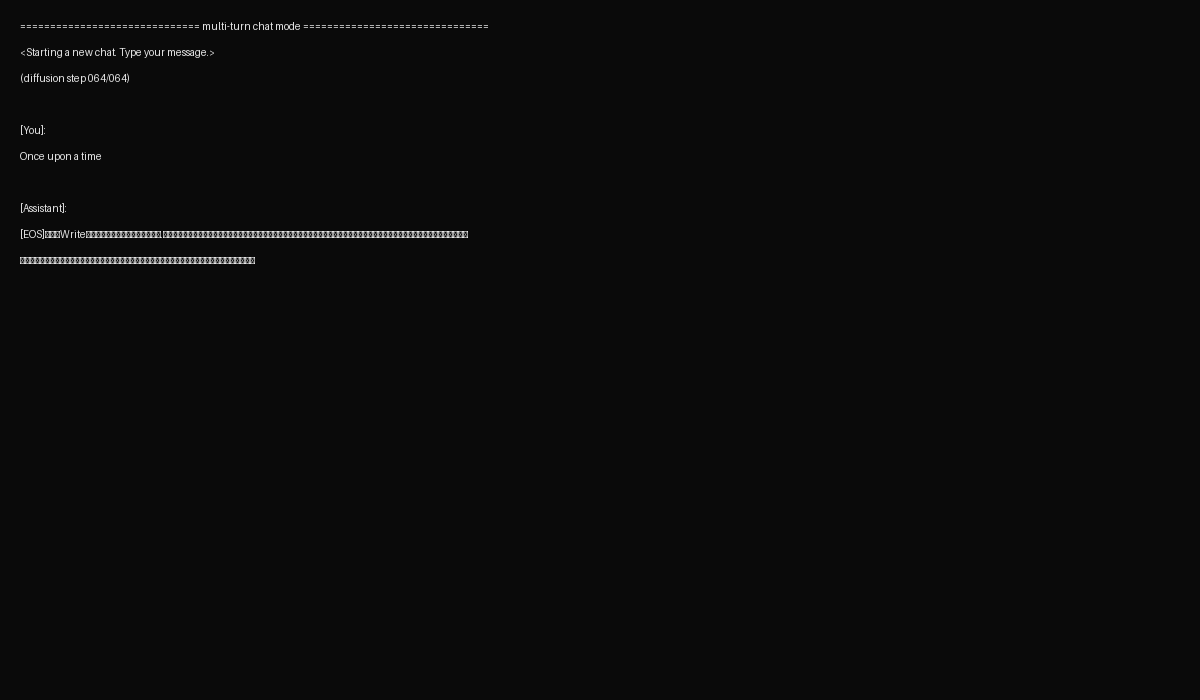

In [22]:
from IPython.display import Image as IPyImage, display
display(IPyImage(filename="inference.gif"))